# ETAD vs IMPROVE EC-Matched Comparisons

Question: when IMPROVE rows are selected to match ETAD/Addis on EC alone, do they look like ETAD in HIPS/fAbs space?

This notebook compares actual row-level ETAD/SPARTAN filters against two IMPROVE subsets:

1. IMPROVE rows with estimated EC mass on the filter inside the ETAD p05-p95 range (`7,196` rows in the previous task map).
2. IMPROVE rows with EC concentration inside the ETAD p05-p95 range (`399` rows in the previous task map).

The key distinction is intentional: EC concentration, EC mass on the filter, and EC surface loading are related but not interchangeable. The filter-loading question should prioritize mass/surface loading, while the chemistry comparison can still inspect concentration-matched rows.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path('../..').resolve()
FTIR = ROOT / 'research' / 'ftir_hips_chem'
IMPROVE = ROOT / 'research' / 'improve_hips_offset'
sys.path.insert(0, str(FTIR / 'scripts'))
from plotting.utils import calculate_regression_stats

UNIFIED_FILTER = FTIR / 'Filter Data' / 'unified_filter_dataset.pkl'
IMPROVE_CLEAN = FTIR / 'output' / 'improve_high_fabs_comparison' / 'improve_valid_cleaned.csv'
OUT = IMPROVE / 'output' / 'etad_vs_improve_ec_matched_comparisons'
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})

COLORS = {
    'ETAD': '#E45756',
    'IMPROVE EC mass-estimate match': '#F58518',
    'IMPROVE EC concentration match': '#4C78A8',
    'IMPROVE background': '#9AA4B2',
}
FIGURES = []


def savefig(fig, name, caption):
    path = OUT / name
    fig.savefig(path, dpi=180, bbox_inches='tight')
    FIGURES.append({'figure': name, 'path': str(path.relative_to(ROOT)), 'caption': caption})
    plt.close(fig)
    return path


def describe_group(df, group_name):
    metrics = {
        'n': len(df),
        'sites': df['SiteCode'].nunique() if 'SiteCode' in df.columns else df['Site'].nunique(),
        'fAbs_median': df['fAbs'].median(),
        'fAbs_p05': df['fAbs'].quantile(.05),
        'fAbs_p95': df['fAbs'].quantile(.95),
        'EC_conc_median': df['EC_conc'].median(),
        'EC_mass_ug_median': df['EC_mass_ug'].median(),
        'EC_surface_ug_cm2_median': df['EC_surface_ug_cm2'].median(),
        'fAbs_per_EC_median': df['fAbs_per_EC'].median(),
        'fAbs_in_ETAD_p05p95_pct': 100 * df['fAbs_in_etad_p05p95'].mean(),
    }
    return {'group': group_name, **metrics}


def regression_stats(df, xcol='EC_conc', ycol='fAbs'):
    s = calculate_regression_stats(df, xcol, ycol, positive_only=True)
    d = df[[xcol, ycol]].replace([np.inf, -np.inf], np.nan).dropna()
    d = d[(d[xcol] > 0) & (d[ycol] > 0)]
    if s is None:
        return {'n': len(d), 'slope': np.nan, 'intercept': np.nan, 'r2': np.nan, 'origin_slope': np.nan}
    return {'n': s['n'], 'slope': s['slope'], 'intercept': s['intercept'], 'r2': s['r2'], 'origin_slope': s['origin_slope']}

print(f'Output: {OUT.relative_to(ROOT)}')

Output: research/improve_hips_offset/output/etad_vs_improve_ec_matched_comparisons


## 1. Rebuild Row-Level ETAD/SPARTAN Reference

The ETAD reference is rebuilt from the unified SPARTAN filter dataset, not from summary tables. `EC_ftir` supplies both concentration and mass loading; HIPS supplies `HIPS_Fabs` and related optical fields.

In [2]:
filter_long = pd.read_pickle(UNIFIED_FILTER)
params = ['EC_ftir', 'HIPS_Fabs', 'HIPS_tau', 'HIPS_T1', 'HIPS_R1', 'HIPS_r', 'HIPS_t']
base_cols = ['Site', 'FilterId', 'SampleDate', 'FilterType', 'LotId', 'DepositArea_cm2', 'Volume_m3', 'Parameter', 'Concentration', 'MassLoading_ug']
sub = filter_long.loc[filter_long['Parameter'].isin(params), base_cols].copy()
wide = sub.pivot_table(
    index=['Site', 'FilterId', 'SampleDate', 'FilterType', 'LotId', 'DepositArea_cm2', 'Volume_m3'],
    columns='Parameter', values='Concentration', aggfunc='first'
).reset_index()
# EC mass loading lives in MassLoading_ug for the EC_ftir rows.
ec_mass = sub.loc[sub['Parameter'].eq('EC_ftir'), ['FilterId', 'MassLoading_ug']].drop_duplicates('FilterId')
wide = wide.merge(ec_mass, on='FilterId', how='left').rename(columns={'MassLoading_ug': 'EC_mass_ug'})
wide['EC_surface_ug_cm2'] = wide['EC_mass_ug'] / wide['DepositArea_cm2']
wide['fAbs_per_EC'] = wide['HIPS_Fabs'] / wide['EC_ftir']
wide['EC_mass_source'] = 'direct SPARTAN MassLoading_ug'
wide['EC_surface_source'] = 'direct mass / DepositArea_cm2'
wide = wide.rename(columns={'EC_ftir': 'EC_conc', 'HIPS_Fabs': 'fAbs'})
spartan = wide[
    wide['EC_conc'].notna() & wide['fAbs'].notna() & wide['EC_mass_ug'].notna() & wide['EC_surface_ug_cm2'].notna()
    & (wide['EC_conc'] > 0) & (wide['fAbs'] > 0) & (wide['EC_mass_ug'] > 0)
].copy()
etad = spartan.loc[spartan['Site'].eq('ETAD')].copy()

bounds = pd.DataFrame([
    {'metric': 'fAbs', 'p05': etad['fAbs'].quantile(.05), 'median': etad['fAbs'].median(), 'p95': etad['fAbs'].quantile(.95)},
    {'metric': 'EC_conc', 'p05': etad['EC_conc'].quantile(.05), 'median': etad['EC_conc'].median(), 'p95': etad['EC_conc'].quantile(.95)},
    {'metric': 'EC_mass_ug', 'p05': etad['EC_mass_ug'].quantile(.05), 'median': etad['EC_mass_ug'].median(), 'p95': etad['EC_mass_ug'].quantile(.95)},
    {'metric': 'EC_surface_ug_cm2', 'p05': etad['EC_surface_ug_cm2'].quantile(.05), 'median': etad['EC_surface_ug_cm2'].median(), 'p95': etad['EC_surface_ug_cm2'].quantile(.95)},
])
bounds.to_csv(OUT / 'etad_row_level_bounds.csv', index=False)
display(bounds)
display(etad[['Site', 'FilterId', 'SampleDate', 'EC_conc', 'EC_mass_ug', 'EC_surface_ug_cm2', 'fAbs', 'fAbs_per_EC']].head())

,metric,p05,median,p95
0,fAbs,34.680930,47.132129,68.043457
1,EC_conc,2.364730,4.624584,9.600472
2,EC_mass_ug,16.679911,33.503921,69.329343
3,EC_surface_ug_cm2,4.725187,9.491196,19.640041


,Site,FilterId,SampleDate,EC_conc,EC_mass_ug,EC_surface_ug_cm2,fAbs,fAbs_per_EC
186,ETAD,ETAD-0001-1,2023-01-21,3.566175,24.752106,7.011928,55.292322,15.504659
187,ETAD,ETAD-0002-2,2023-01-24,2.711555,18.820361,5.331547,44.160320,16.285976
188,ETAD,ETAD-0003-3,2023-01-27,2.210294,15.341211,4.345952,37.512474,16.971710
189,ETAD,ETAD-0004-4,2023-01-30,2.428105,17.062777,4.833648,40.993997,16.883126
190,ETAD,ETAD-0005-5,2023-02-02,2.762804,19.414776,5.499937,46.242781,16.737626


## 2. Build the Two IMPROVE EC-Matched Subsets

The same ETAD p05-p95 bounds are applied to the cleaned post-2003 IMPROVE FED pull.

### Mass-Loading Provenance

ETAD/SPARTAN and IMPROVE do not provide mass loading in the same way in the files currently available here.

- ETAD/SPARTAN: `EC_mass_ug` is direct row-level `MassLoading_ug` for `Parameter == "EC_ftir"` in `unified_filter_dataset.pkl`.
- IMPROVE/FED current pull: no direct EC mass/loading output field is present in the local Excel exports. The available fields are concentration (`ECf_Val`) plus `FlowRate_Val` and `SampDur_Val`, so IMPROVE `EC_mass_ug` below is an estimate: `ECf_Val * FlowRate_Val * SampDur_Val / 1000`.

If we later get an IMPROVE direct mass/loading export, this is the cell to swap out.

In [3]:
provenance = pd.DataFrame([
    {
        'dataset': 'ETAD/SPARTAN',
        'ec_concentration_source': 'unified_filter_dataset.pkl: Concentration where Parameter == EC_ftir',
        'ec_mass_source': 'direct MassLoading_ug where Parameter == EC_ftir',
        'ec_surface_source': 'MassLoading_ug / DepositArea_cm2',
    },
    {
        'dataset': 'IMPROVE/FED current pull',
        'ec_concentration_source': 'ECf_Val in local FED Excel/Data sheet',
        'ec_mass_source': 'estimated as ECf_Val * FlowRate_Val * SampDur_Val / 1000',
        'ec_surface_source': 'estimated EC mass / assumed IMPROVE deposit area used in prior workflow',
    },
])
provenance.to_csv(OUT / 'mass_loading_provenance.csv', index=False)
display(provenance)

,dataset,ec_concentration_source,ec_mass_source,ec_surface_source
0,ETAD/SPARTAN,unified_filter_dataset.pkl: Concentration wher...,direct MassLoading_ug where Parameter == EC_ftir,MassLoading_ug / DepositArea_cm2
1,IMPROVE/FED current pull,ECf_Val in local FED Excel/Data sheet,estimated as ECf_Val * FlowRate_Val * SampDur_...,estimated EC mass / assumed IMPROVE deposit ar...


In [4]:
usecols = [
    'Dataset', 'SiteCode', 'POC', 'Date', 'AuxID', 'SiteName', 'State', 'Latitude', 'Longitude',
    'ECf_Val', 'fAbs_Val', 'volume_m3', 'EC_loading_ug', 'EC_loading_ug_cm2_primary',
    'OC_EC', 'FE_EC', 'SOIL_EC', 'MF_EC', 'year', 'month', 'rt_available',
]
improve = pd.read_csv(IMPROVE_CLEAN, usecols=lambda c: c in usecols, low_memory=False)
improve['Date'] = pd.to_datetime(improve['Date'])
improve = improve[
    improve['ECf_Val'].notna() & improve['fAbs_Val'].notna()
    & (improve['ECf_Val'] > 0) & (improve['fAbs_Val'] > 0)
].copy()
improve['EC_conc'] = improve['ECf_Val']
improve['fAbs'] = improve['fAbs_Val']
improve['EC_mass_ug'] = improve['EC_loading_ug']
improve['EC_surface_ug_cm2'] = improve['EC_loading_ug_cm2_primary']
improve['fAbs_per_EC'] = improve['fAbs'] / improve['EC_conc']
improve['EC_mass_source'] = 'estimated from ECf_Val * volume_m3'
improve['EC_surface_source'] = 'estimated mass / assumed area'
improve['volume_source'] = 'FlowRate_Val * SampDur_Val / 1000 from current FED pull'

b = bounds.set_index('metric')
fabs_p05, fabs_p95 = b.loc['fAbs', ['p05', 'p95']]
ec_conc_p05, ec_conc_p95 = b.loc['EC_conc', ['p05', 'p95']]
ec_mass_p05, ec_mass_p95 = b.loc['EC_mass_ug', ['p05', 'p95']]
ec_surface_p05, ec_surface_p95 = b.loc['EC_surface_ug_cm2', ['p05', 'p95']]

improve_loading = improve[improve['EC_mass_ug'].notna() & improve['EC_surface_ug_cm2'].notna()].copy()
improve_mass_match = improve_loading[improve_loading['EC_mass_ug'].between(ec_mass_p05, ec_mass_p95, inclusive='both')].copy()
improve_conc_match = improve_loading[improve_loading['EC_conc'].between(ec_conc_p05, ec_conc_p95, inclusive='both')].copy()

for df in [etad, improve_loading, improve_mass_match, improve_conc_match]:
    df['fAbs_in_etad_p05p95'] = df['fAbs'].between(fabs_p05, fabs_p95, inclusive='both')

subset_summary = pd.DataFrame([
    describe_group(etad.assign(SiteCode='ETAD'), 'ETAD row-level reference'),
    describe_group(improve_mass_match, 'IMPROVE EC mass-estimate p05-p95 match'),
    describe_group(improve_conc_match, 'IMPROVE EC concentration p05-p95 match'),
])
subset_summary.to_csv(OUT / 'subset_summary.csv', index=False)
display(subset_summary.round(3))

print('Expected previous counts: mass match ~7,196; concentration match ~399')
print('Current counts:', len(improve_mass_match), len(improve_conc_match))

,group,n,sites,fAbs_median,fAbs_p05,fAbs_p95,EC_conc_median,EC_mass_ug_median,EC_surface_ug_cm2_median,fAbs_per_EC_median,fAbs_in_ETAD_p05p95_pct
0,ETAD row-level reference,190,1,47.132,34.681,68.043,4.625,33.504,9.491,10.158,90.000
1,IMPROVE EC mass-estimate p05-p95 match,7196,166,7.220,4.178,15.730,0.789,23.861,6.817,8.720,0.139
2,IMPROVE EC concentration p05-p95 match,399,78,17.050,9.195,37.325,2.923,84.573,24.164,5.446,6.015


Expected previous counts: mass match ~7,196; concentration match ~399
Current counts: 7196 399


## 3. Distribution Comparisons

These panels answer whether EC-matched IMPROVE rows occupy the same fAbs and fAbs/EC regimes as ETAD.

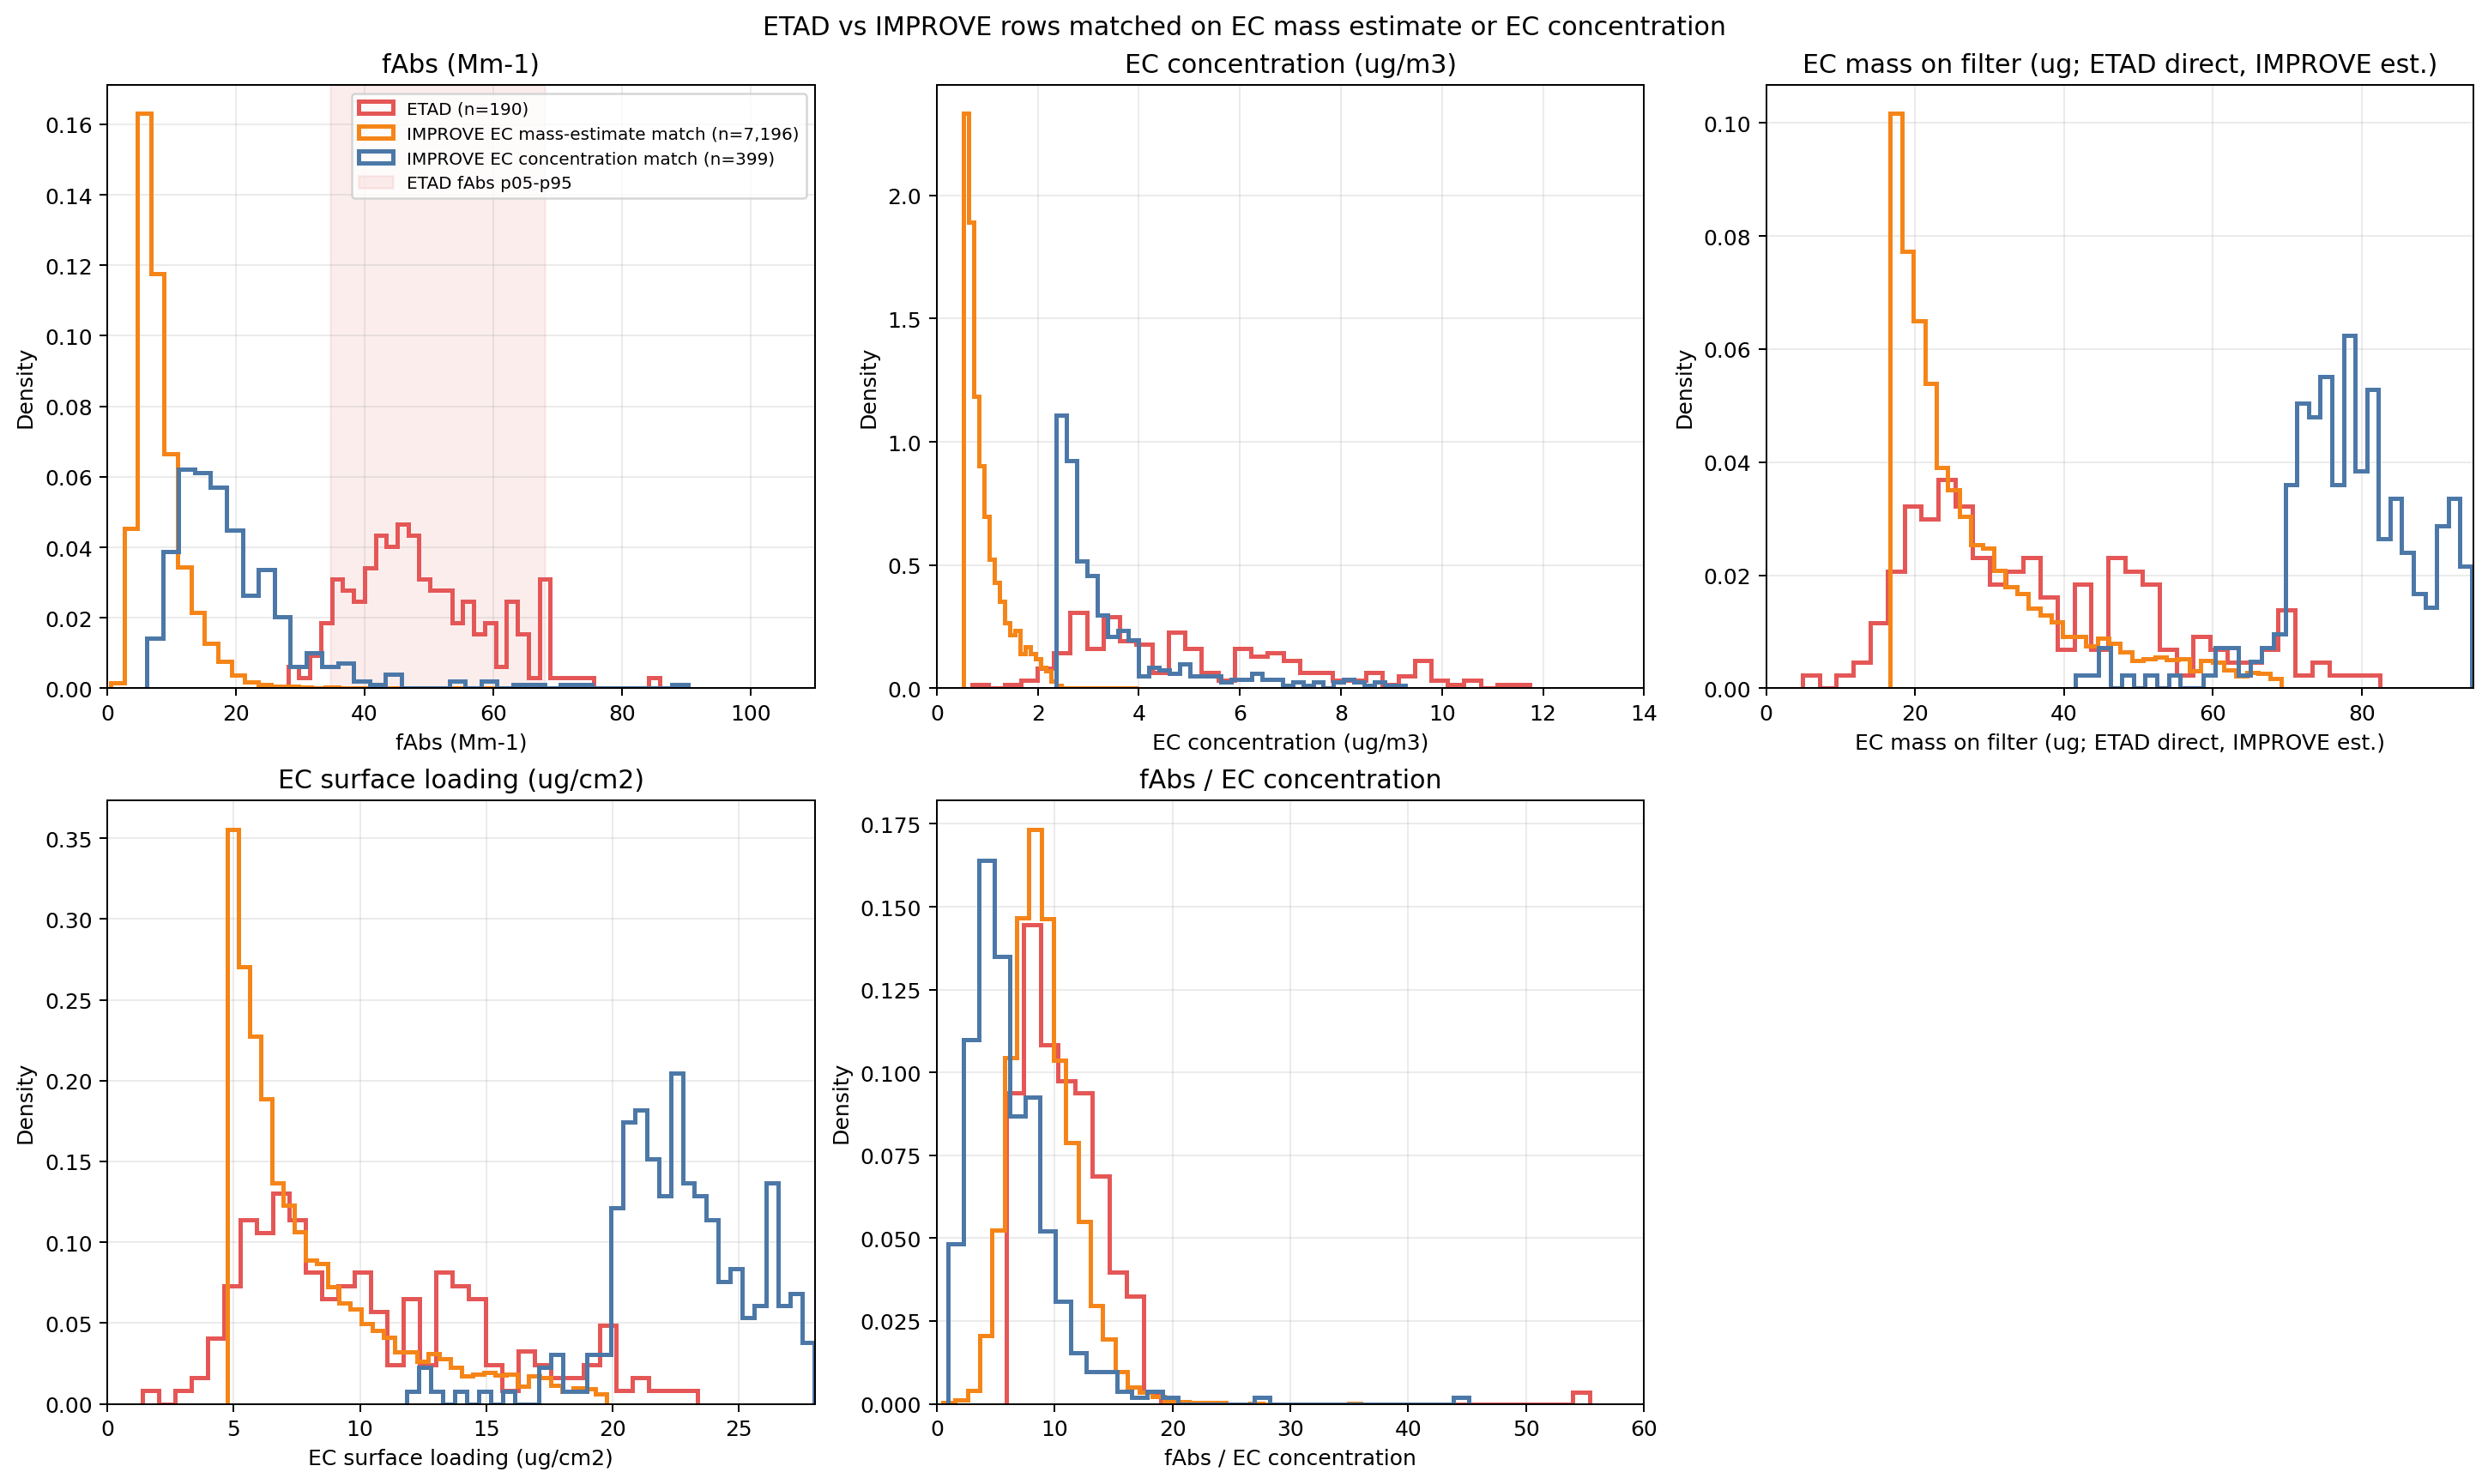

In [5]:
plot_groups = [
    ('ETAD', etad, COLORS['ETAD']),
    ('IMPROVE EC mass-estimate match', improve_mass_match, COLORS['IMPROVE EC mass-estimate match']),
    ('IMPROVE EC concentration match', improve_conc_match, COLORS['IMPROVE EC concentration match']),
]
metrics = [
    ('fAbs', 'fAbs (Mm-1)', (0, 110)),
    ('EC_conc', 'EC concentration (ug/m3)', (0, 14)),
    ('EC_mass_ug', 'EC mass on filter (ug; ETAD direct, IMPROVE est.)', (0, 95)),
    ('EC_surface_ug_cm2', 'EC surface loading (ug/cm2)', (0, 28)),
    ('fAbs_per_EC', 'fAbs / EC concentration', (0, 60)),
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9.5), constrained_layout=True)
axes = axes.ravel()
for ax, (col, label, xlim) in zip(axes, metrics):
    for name, df, color in plot_groups:
        data = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        data = data[(data >= xlim[0]) & (data <= xlim[1])]
        ax.hist(data, bins=34, density=True, histtype='step', lw=2, color=color, label=f'{name} (n={len(df):,})')
    if col == 'fAbs':
        ax.axvspan(fabs_p05, fabs_p95, color=COLORS['ETAD'], alpha=0.10, label='ETAD fAbs p05-p95')
    ax.set_xlim(*xlim)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(label)
axes[-1].axis('off')
axes[0].legend(loc='upper right', frameon=True, fontsize=8)
fig.suptitle('ETAD vs IMPROVE rows matched on EC mass estimate or EC concentration')
path = savefig(fig, 'fig01_distribution_comparison.png', 'Distribution comparison of ETAD row-level filters against IMPROVE EC-mass-estimate-matched and EC-concentration-matched subsets.')
Image(filename=str(path))

## 4. fAbs vs EC: Do EC-Matched IMPROVE Rows Follow ETAD?

The same EC range can still have much lower fAbs. These scatter plots make that visible.

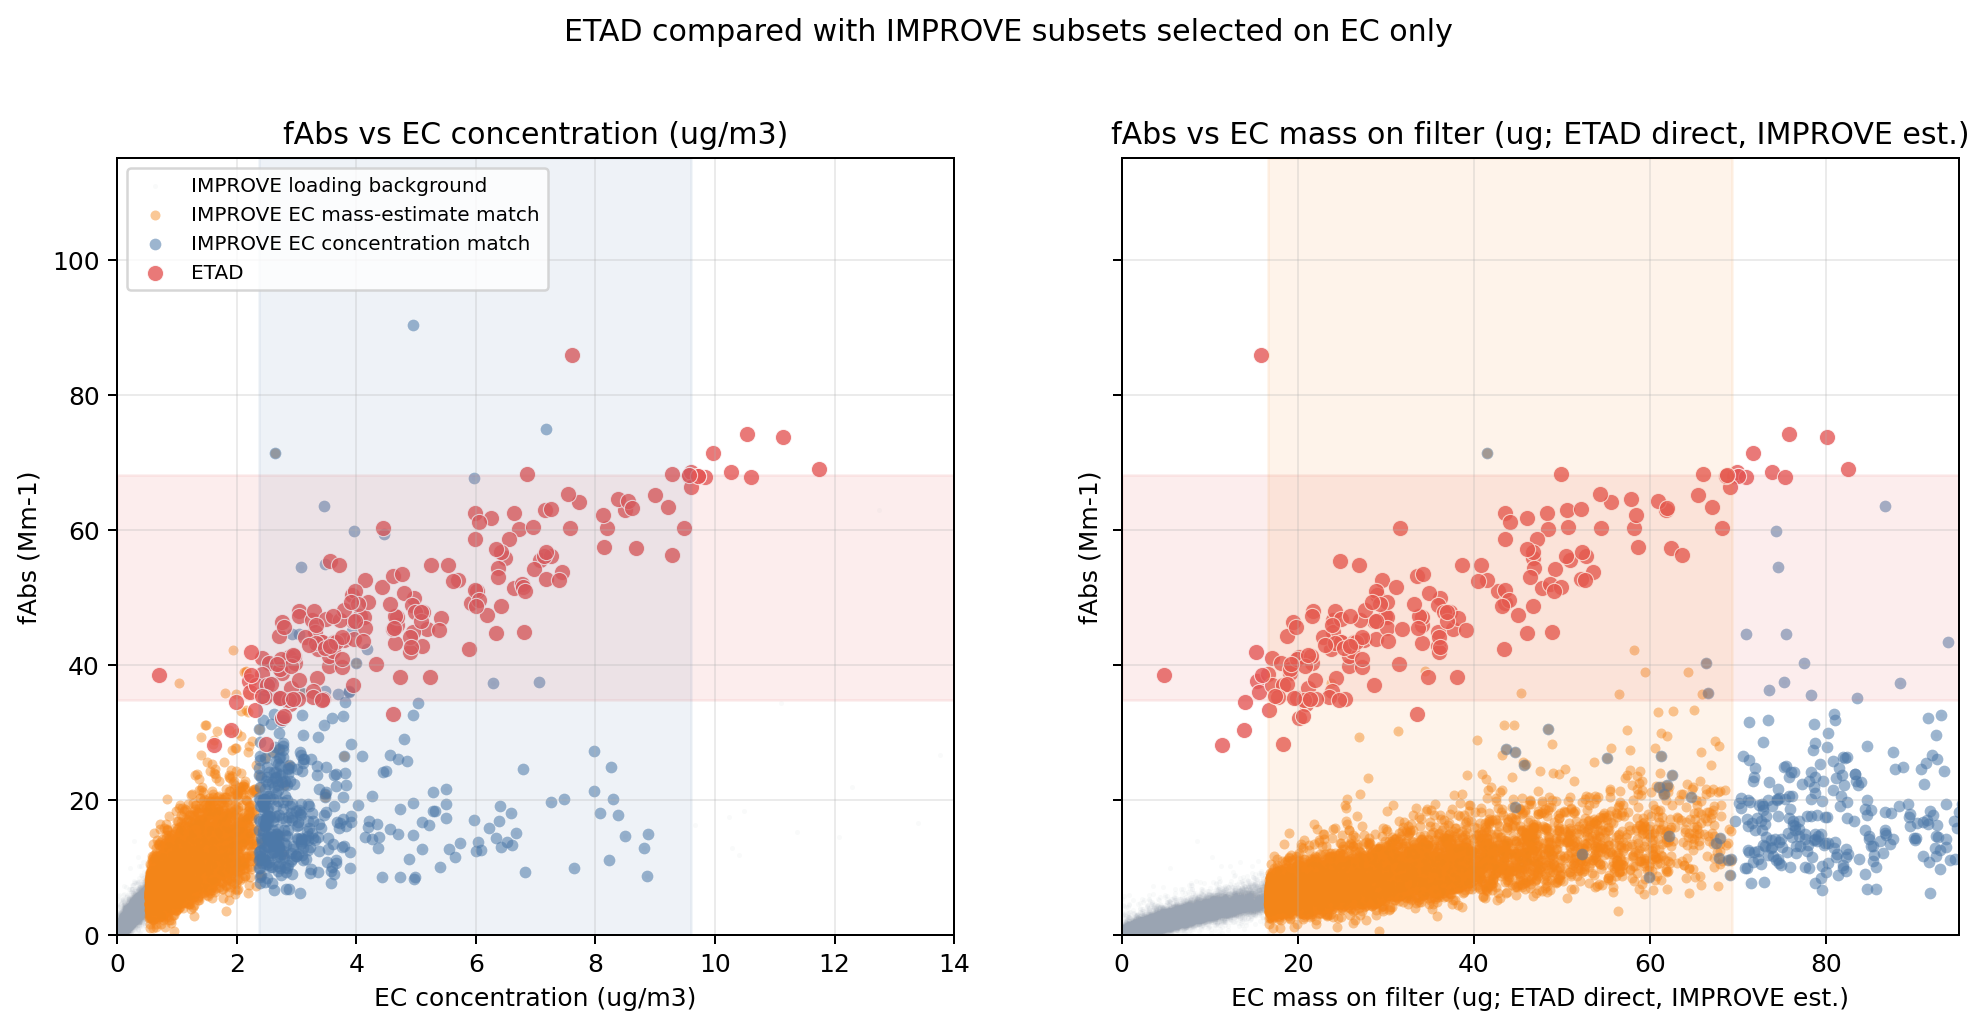

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.6), sharey=True)
background = improve_loading.sample(min(len(improve_loading), 70000), random_state=7)
for ax, xcol, xlabel, xlim in [
    (axes[0], 'EC_conc', 'EC concentration (ug/m3)', (0, 14)),
    (axes[1], 'EC_mass_ug', 'EC mass on filter (ug; ETAD direct, IMPROVE est.)', (0, 95)),
]:
    ax.scatter(background[xcol], background['fAbs'], s=4, alpha=0.055, color=COLORS['IMPROVE background'], linewidths=0, rasterized=True, label='IMPROVE loading background')
    ax.scatter(improve_mass_match[xcol], improve_mass_match['fAbs'], s=16, alpha=0.45, color=COLORS['IMPROVE EC mass-estimate match'], linewidths=0, label='IMPROVE EC mass-estimate match')
    ax.scatter(improve_conc_match[xcol], improve_conc_match['fAbs'], s=22, alpha=0.55, color=COLORS['IMPROVE EC concentration match'], linewidths=0, label='IMPROVE EC concentration match')
    ax.scatter(etad[xcol], etad['fAbs'], s=42, alpha=0.8, color=COLORS['ETAD'], edgecolor='white', linewidth=0.45, label='ETAD')
    ax.axhspan(fabs_p05, fabs_p95, color=COLORS['ETAD'], alpha=0.10)
    if xcol == 'EC_conc':
        ax.axvspan(ec_conc_p05, ec_conc_p95, color=COLORS['IMPROVE EC concentration match'], alpha=0.09)
    else:
        ax.axvspan(ec_mass_p05, ec_mass_p95, color=COLORS['IMPROVE EC mass-estimate match'], alpha=0.09)
    ax.set_xlim(*xlim)
    ax.set_ylim(0, 115)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('fAbs (Mm-1)')
    ax.set_title(f'fAbs vs {xlabel}')
axes[0].legend(loc='upper left', frameon=True, fontsize=8)
fig.suptitle('ETAD compared with IMPROVE subsets selected on EC only', y=1.02)
path = savefig(fig, 'fig02_fabs_vs_ec_matched_subsets.png', 'Scatter comparison showing that EC-matched IMPROVE rows generally do not occupy the same high-fAbs regime as ETAD.')
Image(filename=str(path))

## 5. Regression and MAC-Style Slopes

These regressions are descriptive. The IMPROVE subsets are selected on EC ranges, so slopes are not independent calibration estimates; they show whether fAbs response is ETAD-like within the matched windows.

,group,n,slope,intercept,r2,origin_slope
0,ETAD,190,4.023,28.324,0.764,8.632
1,IMPROVE EC mass-estimate match,7196,6.962,1.709,0.511,8.493
2,IMPROVE EC concentration match,399,3.048,10.016,0.047,5.522


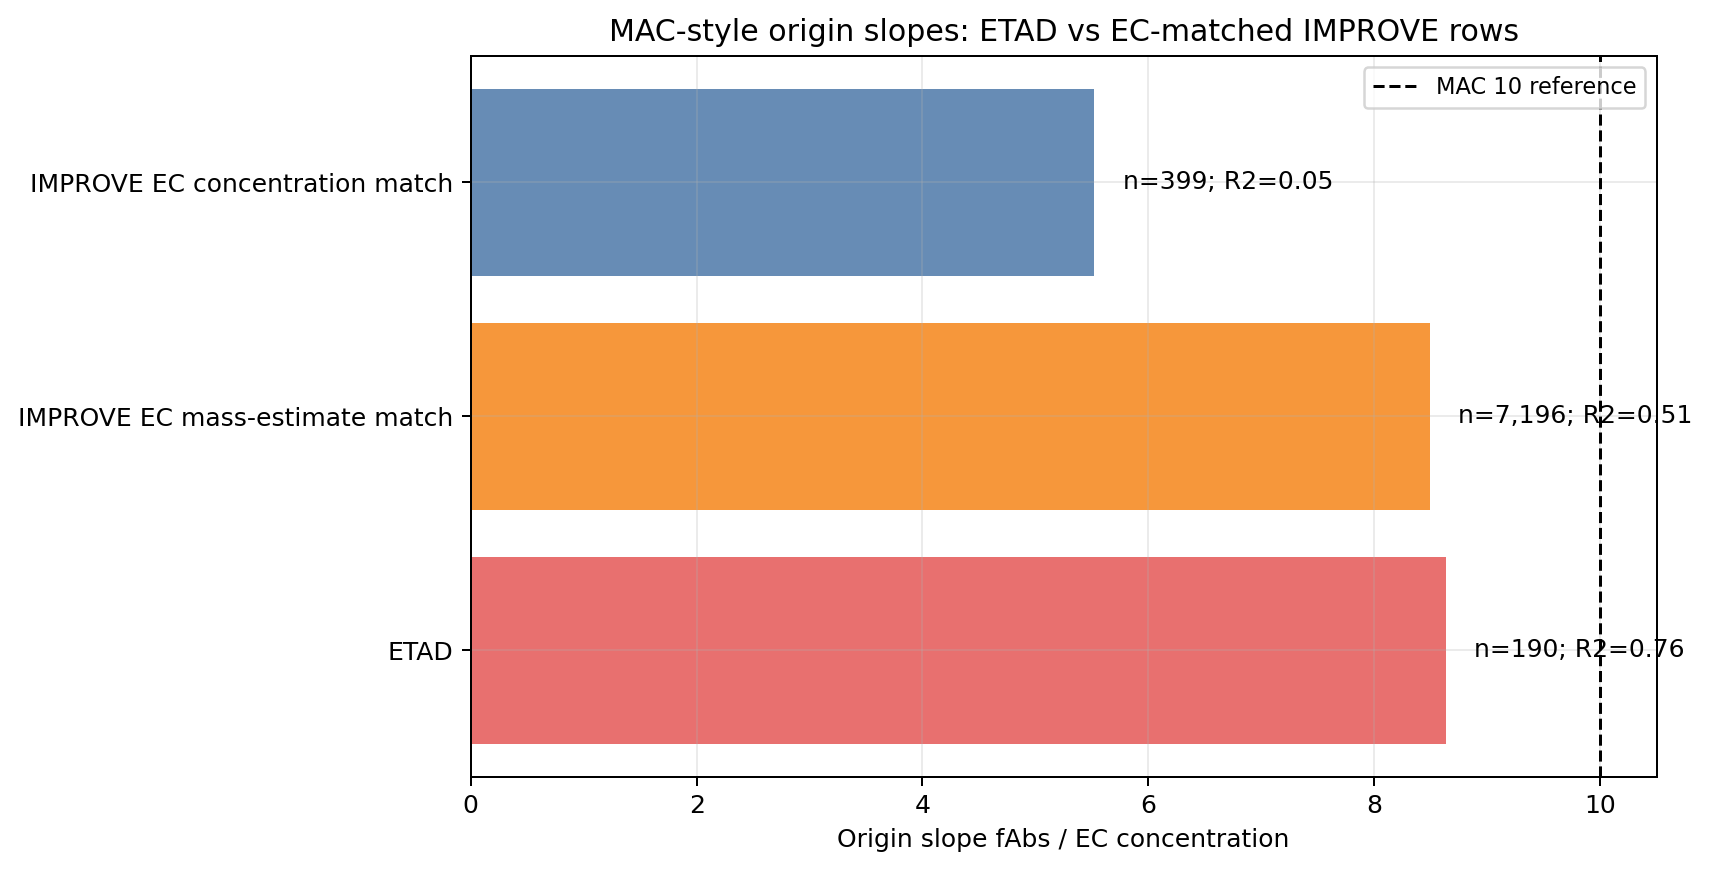

In [7]:
reg_rows = []
for name, df, _ in plot_groups:
    reg = regression_stats(df, 'EC_conc', 'fAbs')
    reg_rows.append({'group': name, **reg})
regression_summary = pd.DataFrame(reg_rows)
regression_summary.to_csv(OUT / 'regression_summary.csv', index=False)
display(regression_summary.round(3))

fig, ax = plt.subplots(figsize=(8.5, 5.2))
reg_plot = regression_summary.copy()
y = np.arange(len(reg_plot))
colors = [COLORS[g] for g in reg_plot['group']]
ax.barh(y, reg_plot['origin_slope'], color=colors, alpha=0.85)
for i, row in reg_plot.iterrows():
    ax.text(row['origin_slope'] + 0.25, i, f"n={int(row['n']):,}; R2={row['r2']:.2f}", va='center')
ax.axvline(10, color='black', ls='--', lw=1.2, label='MAC 10 reference')
ax.set_yticks(y, reg_plot['group'])
ax.set_xlabel('Origin slope fAbs / EC concentration')
ax.set_title('MAC-style origin slopes: ETAD vs EC-matched IMPROVE rows')
ax.legend(frameon=True)
path = savefig(fig, 'fig03_origin_slope_comparison.png', 'MAC-style origin slopes for ETAD and IMPROVE EC-matched subsets.')
Image(filename=str(path))

## 6. Which IMPROVE Sites Contribute the EC-Matched Rows?

The mass-matched group is broad across the network; the concentration-matched group is smaller but still spread across many sites. This is useful for deciding whether the comparison is dominated by one site/event.

,subset,SiteCode,SiteName,State,rows,median_fAbs,median_EC,median_EC_mass_ug,median_EC_surface_ug_cm2,pct_fAbs_ETAD_range
0,EC mass match,BIRM1,North Birmingham,AL,479,8.10,0.95,29.16,8.33,0.00
1,EC mass match,NOGA1,Nogales,AZ,455,11.28,0.92,28.11,8.03,0.66
2,EC mass match,PHOE1,Phoenix,AZ,395,10.43,1.00,30.52,8.72,0.51
3,EC mass match,PHOE5,Phoenix Colocated Sampler,AZ,391,10.12,0.99,30.56,8.73,0.26
4,EC mass match,FRES1,Fresno,CA,361,9.08,0.97,29.78,8.51,0.28
5,EC mass match,ATLA1,South Dekalb,GA,347,7.98,0.89,27.22,7.78,0.00
6,EC mass match,PUSO1,Puget Sound,WA,281,8.20,0.77,23.36,6.67,0.00
7,EC mass match,PITT1,Lawrenceville,PA,252,6.80,0.76,23.01,6.58,0.00
8,EC mass match,BYIS1,Baengnyeong Island,NaN,162,9.50,0.94,28.41,8.12,0.00
9,EC mass match,CHAS1,Chassahowitzka NWR,FL,159,7.22,0.75,22.90,6.54,0.00


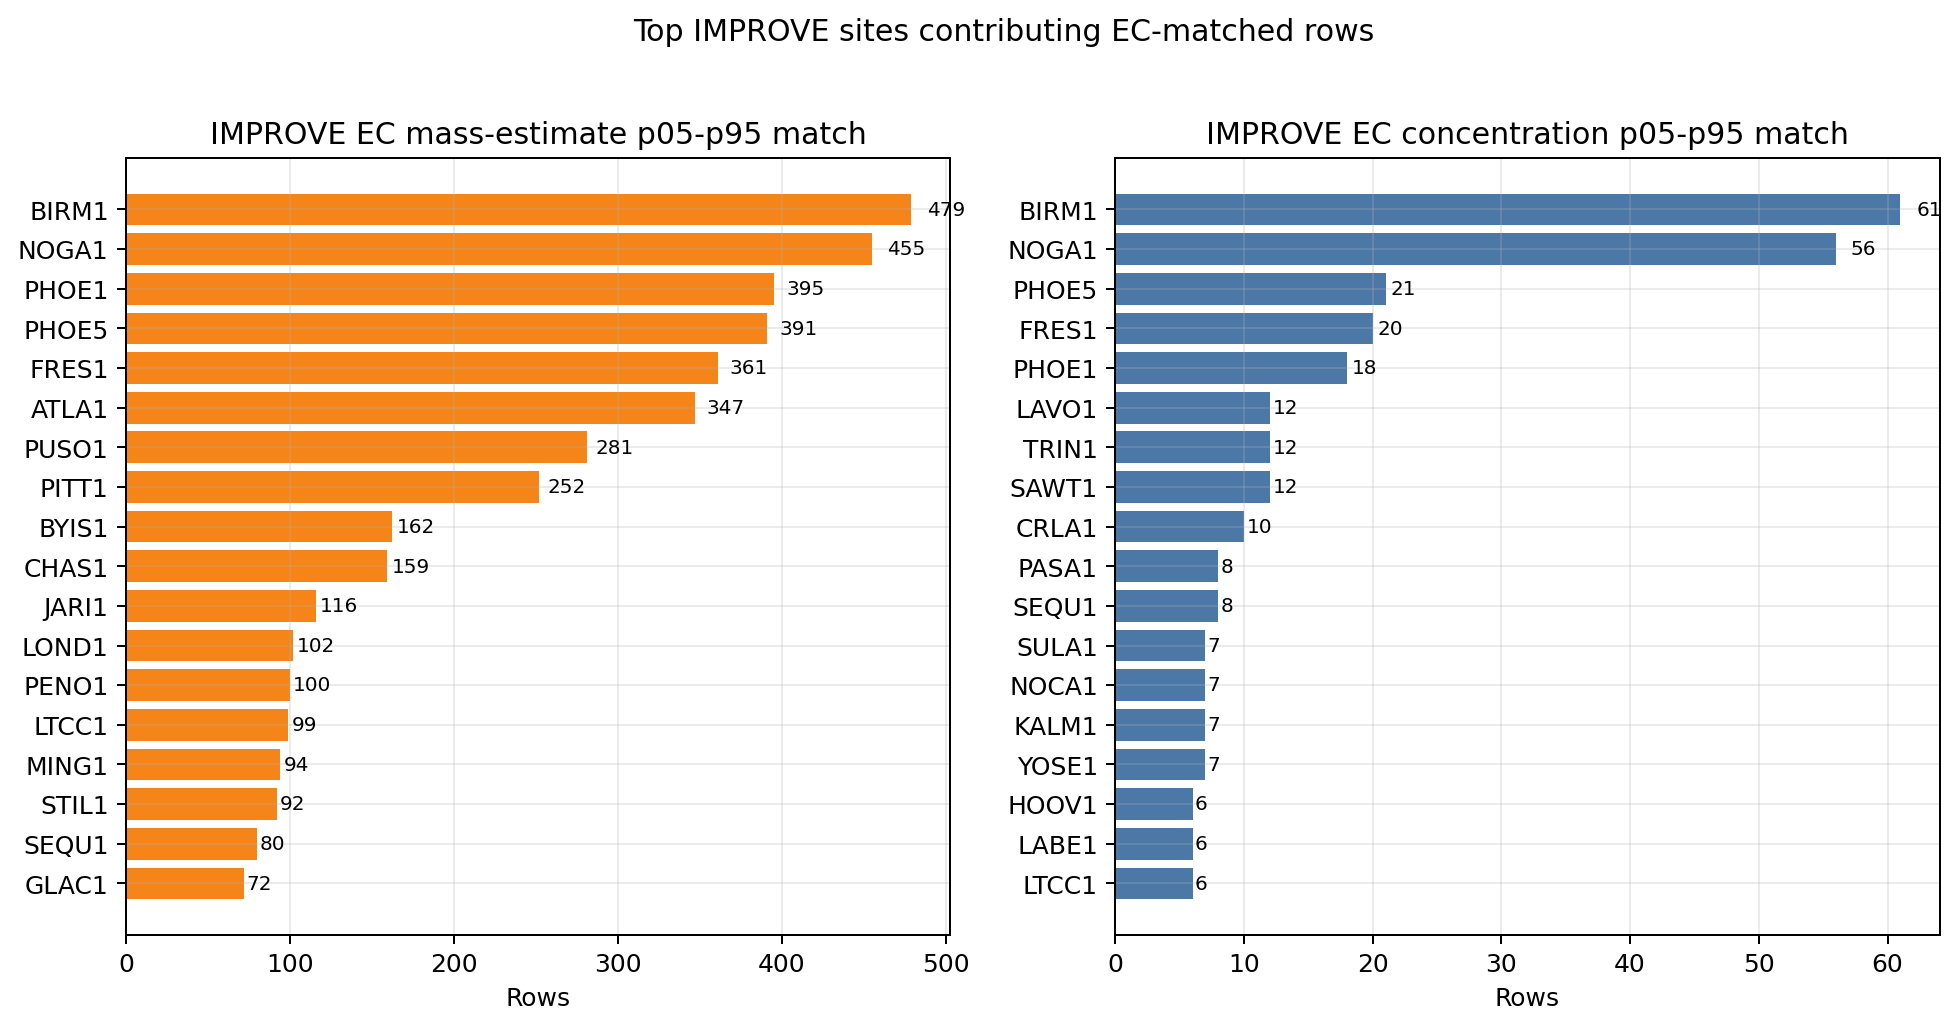

In [8]:
def top_sites(df, label, n=15):
    out = df.groupby(['SiteCode', 'SiteName', 'State'], dropna=False).agg(
        rows=('fAbs', 'size'),
        median_fAbs=('fAbs', 'median'),
        median_EC=('EC_conc', 'median'),
        median_EC_mass_ug=('EC_mass_ug', 'median'),
        median_EC_surface_ug_cm2=('EC_surface_ug_cm2', 'median'),
        pct_fAbs_ETAD_range=('fAbs_in_etad_p05p95', lambda s: 100*s.mean()),
    ).reset_index().sort_values('rows', ascending=False).head(n)
    out.insert(0, 'subset', label)
    return out

top_site_summary = pd.concat([
    top_sites(improve_mass_match, 'EC mass match'),
    top_sites(improve_conc_match, 'EC concentration match'),
], ignore_index=True)
top_site_summary.to_csv(OUT / 'top_site_summary.csv', index=False)
display(top_site_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharex=False)
for ax, df, label, color in [
    (axes[0], improve_mass_match, 'IMPROVE EC mass-estimate p05-p95 match', COLORS['IMPROVE EC mass-estimate match']),
    (axes[1], improve_conc_match, 'IMPROVE EC concentration p05-p95 match', COLORS['IMPROVE EC concentration match']),
]:
    counts = df.groupby('SiteCode').size().sort_values(ascending=False).head(18).sort_values()
    ax.barh(counts.index, counts.values, color=color)
    ax.set_title(label)
    ax.set_xlabel('Rows')
    for y_i, value in enumerate(counts.values):
        ax.text(value * 1.02, y_i, f'{value:,}', va='center', fontsize=8)
fig.suptitle('Top IMPROVE sites contributing EC-matched rows', y=1.02)
path = savefig(fig, 'fig04_top_sites_for_ec_matched_rows.png', 'Top contributing IMPROVE sites for EC mass-estimate-matched and EC concentration-matched subsets.')
Image(filename=str(path))

## 7. Date Context

These rows are mostly recent because loading calculations require flow/duration metadata in the current pull. That matters for interpreting post-2003 coverage.

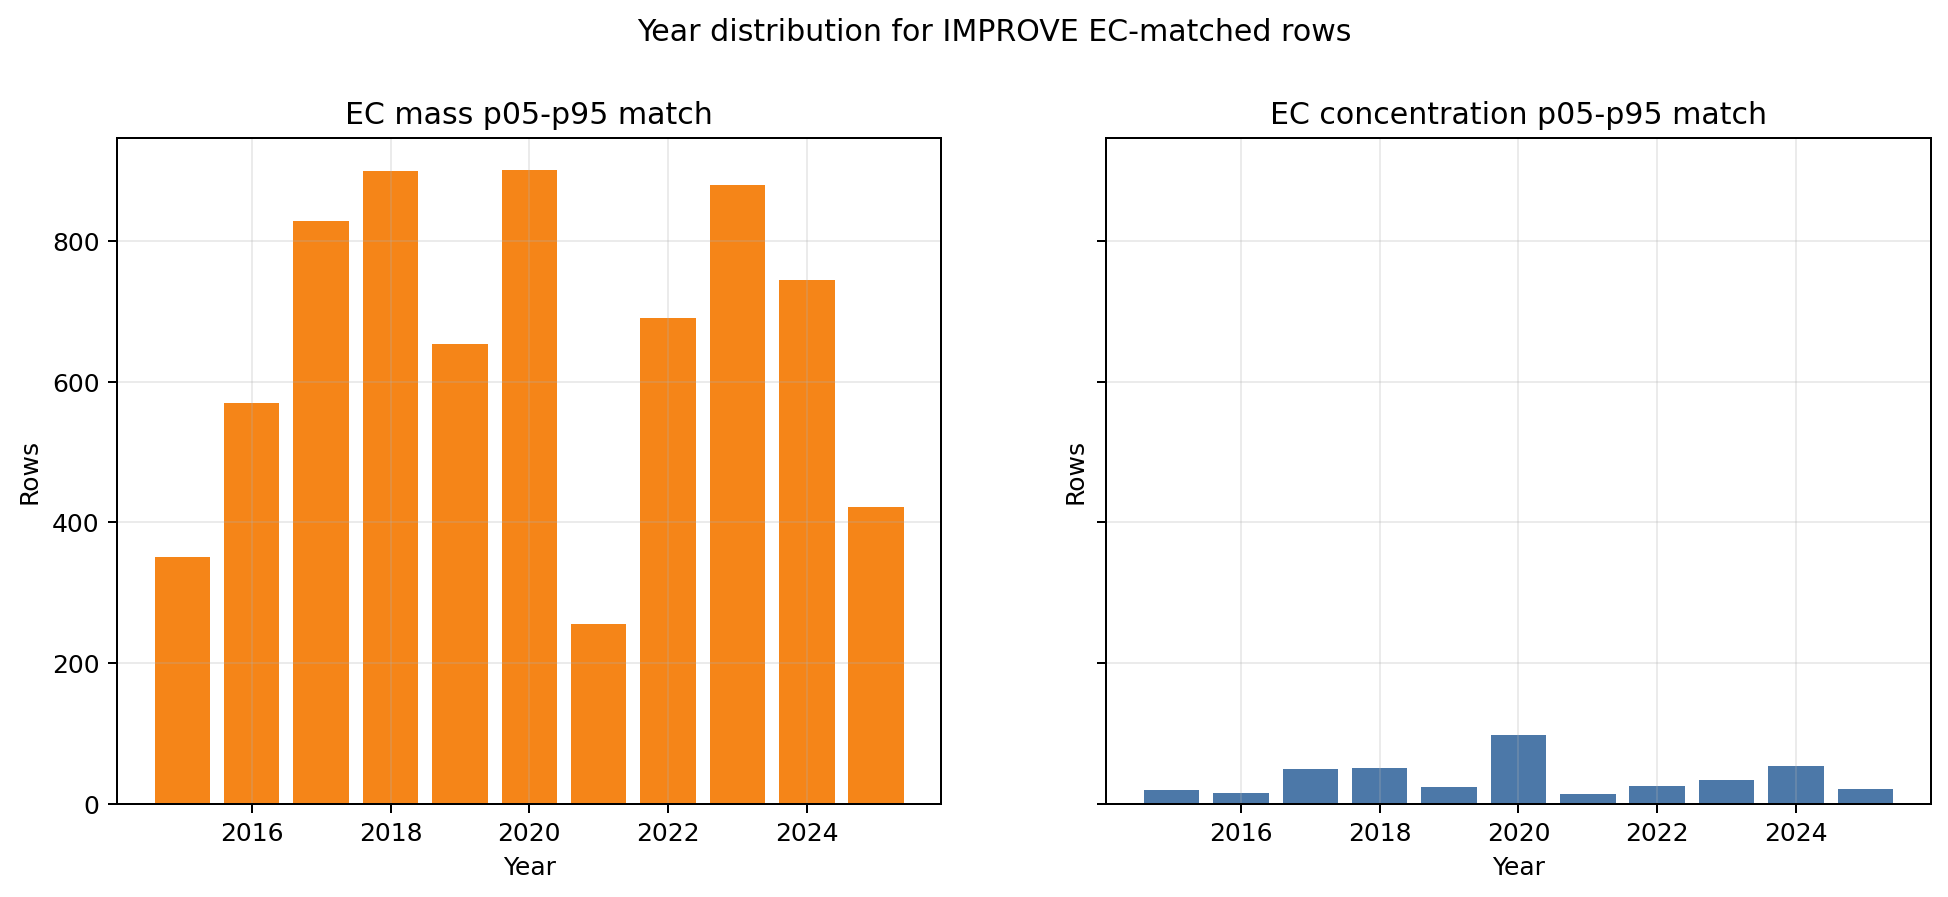

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, df, label, color in [
    (axes[0], improve_mass_match, 'EC mass p05-p95 match', COLORS['IMPROVE EC mass-estimate match']),
    (axes[1], improve_conc_match, 'EC concentration p05-p95 match', COLORS['IMPROVE EC concentration match']),
]:
    counts = df.groupby(df['Date'].dt.year).size()
    ax.bar(counts.index, counts.values, color=color)
    ax.set_title(label)
    ax.set_xlabel('Year')
    ax.set_ylabel('Rows')
fig.suptitle('Year distribution for IMPROVE EC-matched rows', y=1.02)
path = savefig(fig, 'fig05_year_distribution_ec_matched_rows.png', 'Year distribution for the two IMPROVE EC-matched subsets.')
Image(filename=str(path))

## 8. Candidate Rows Closest to ETAD in Both EC and fAbs

For case-level review, this table ranks EC-matched IMPROVE rows by normalized distance to the ETAD median in fAbs, EC concentration, EC mass, and EC surface loading.

In [10]:
med = bounds.set_index('metric')['median']
scale = (bounds.set_index('metric')['p95'] - bounds.set_index('metric')['p05']).replace(0, np.nan)
review = improve_loading.copy()
review['distance_to_etad_median'] = np.sqrt(
    ((review['fAbs'] - med['fAbs']) / scale['fAbs']) ** 2
    + ((review['EC_conc'] - med['EC_conc']) / scale['EC_conc']) ** 2
    + ((review['EC_mass_ug'] - med['EC_mass_ug']) / scale['EC_mass_ug']) ** 2
    + ((review['EC_surface_ug_cm2'] - med['EC_surface_ug_cm2']) / scale['EC_surface_ug_cm2']) ** 2
)
review['ec_mass_match'] = review['EC_mass_ug'].between(ec_mass_p05, ec_mass_p95, inclusive='both')
review['ec_conc_match'] = review['EC_conc'].between(ec_conc_p05, ec_conc_p95, inclusive='both')
review['all_ec_and_fabs_match'] = review['ec_mass_match'] & review['EC_surface_ug_cm2'].between(ec_surface_p05, ec_surface_p95, inclusive='both') & review['fAbs_in_etad_p05p95']
cols = ['SiteCode', 'SiteName', 'State', 'Date', 'fAbs', 'EC_conc', 'EC_mass_ug', 'EC_surface_ug_cm2', 'fAbs_per_EC', 'OC_EC', 'FE_EC', 'SOIL_EC', 'ec_mass_match', 'ec_conc_match', 'all_ec_and_fabs_match', 'distance_to_etad_median']
candidates = review.sort_values('distance_to_etad_median')[cols].head(50)
candidates.to_csv(OUT / 'closest_improve_rows_to_etad_median.csv', index=False)
display(candidates.head(25).round(3))

,SiteCode,SiteName,State,Date,fAbs,EC_conc,EC_mass_ug,EC_surface_ug_cm2,fAbs_per_EC,OC_EC,FE_EC,SOIL_EC,ec_mass_match,ec_conc_match,all_ec_and_fabs_match,distance_to_etad_median
348891,SHMI1,Shamrock Mine,CO,2024-04-24,39.10,2.158,34.449,9.843,18.121,14.128,0.039,0.741,True,False,True,0.418
315997,NOGA1,Nogales,AZ,2024-01-25,35.82,1.813,45.290,12.940,19.761,2.497,0.048,0.718,True,False,True,0.608
246817,CACR1,Caney Creek,AR,2024-02-24,37.20,1.034,23.806,6.802,35.975,7.113,0.022,0.467,True,False,True,0.633
263065,EVER1,Everglades NP,FL,2025-03-20,30.21,1.676,31.416,8.976,18.020,3.301,0.010,0.180,True,False,False,0.653
346754,SEQU1,Sequoia NP,CA,2023-09-21,27.54,2.706,43.691,12.483,10.177,11.608,0.049,0.633,True,True,False,0.702
267656,FRES1,Fresno,CA,2020-09-09,30.98,1.487,43.453,12.415,20.833,10.519,1.252,14.759,True,False,False,0.705
315987,NOGA1,Nogales,AZ,2023-12-26,28.85,1.620,40.376,11.536,17.812,2.635,0.044,0.704,True,False,False,0.713
239173,BRCA1,Bryce Canyon NP,UT,2020-10-09,31.11,1.471,44.509,12.717,21.152,1.533,0.022,0.453,True,False,False,0.715
324511,PENO1,Penobscot,ME,2025-05-07,30.42,2.377,48.376,13.822,12.797,9.155,0.002,0.022,True,True,False,0.715
341831,SAMA1,St. Marks,FL,2024-04-24,29.21,1.404,26.969,7.706,20.810,5.890,0.018,0.265,True,False,False,0.719


## 9. Readout

The practical question is whether matching ETAD on EC alone is enough. This notebook separates the answer by EC definition.

In [11]:
readout = pd.DataFrame([
    {
        'finding': 'Mass source is asymmetric',
        'detail': 'ETAD EC mass is direct SPARTAN MassLoading_ug; IMPROVE EC mass is estimated from ECf concentration and sampled volume because no direct EC mass field is present in the current FED export.',
    },
    {
        'finding': 'EC mass match is common relative to fAbs match',
        'detail': f"IMPROVE has {len(improve_mass_match):,} rows in the ETAD EC mass-estimate p05-p95 range, but only {int(improve_mass_match['fAbs_in_etad_p05p95'].sum()):,} of those also fall in ETAD fAbs p05-p95.",
    },
    {
        'finding': 'EC concentration match is smaller and not equivalent to loading match',
        'detail': f"IMPROVE has {len(improve_conc_match):,} rows in the ETAD EC concentration p05-p95 range; {int(improve_conc_match['fAbs_in_etad_p05p95'].sum()):,} also fall in ETAD fAbs p05-p95.",
    },
    {
        'finding': 'ETAD has much higher fAbs response within matched EC windows',
        'detail': 'The distribution and slope plots show ETAD remains optically distinct even when IMPROVE rows are selected on EC mass or EC concentration.',
    },
    {
        'finding': 'Use EC mass/surface loading for the filter question',
        'detail': 'Mass on the filter is the relevant HIPS loading axis, but the current IMPROVE value is an estimate from ECf concentration and sampled volume; EC concentration matching is a useful diagnostic but should not replace loading-space comparison.',
    },
])
readout.to_csv(OUT / 'readout.csv', index=False)
manifest = pd.DataFrame(FIGURES)
manifest.to_csv(OUT / 'figure_manifest.csv', index=False)
display(readout)
display(manifest)

,finding,detail
0,Mass source is asymmetric,ETAD EC mass is direct SPARTAN MassLoading_ug;...
1,EC mass match is common relative to fAbs match,"IMPROVE has 7,196 rows in the ETAD EC mass-est..."
2,EC concentration match is smaller and not equi...,IMPROVE has 399 rows in the ETAD EC concentrat...
3,ETAD has much higher fAbs response within matc...,The distribution and slope plots show ETAD rem...
4,Use EC mass/surface loading for the filter que...,Mass on the filter is the relevant HIPS loadin...


,figure,path,caption
0,fig01_distribution_comparison.png,research/improve_hips_offset/output/etad_vs_im...,Distribution comparison of ETAD row-level filt...
1,fig02_fabs_vs_ec_matched_subsets.png,research/improve_hips_offset/output/etad_vs_im...,Scatter comparison showing that EC-matched IMP...
2,fig03_origin_slope_comparison.png,research/improve_hips_offset/output/etad_vs_im...,MAC-style origin slopes for ETAD and IMPROVE E...
3,fig04_top_sites_for_ec_matched_rows.png,research/improve_hips_offset/output/etad_vs_im...,Top contributing IMPROVE sites for EC mass-est...
4,fig05_year_distribution_ec_matched_rows.png,research/improve_hips_offset/output/etad_vs_im...,Year distribution for the two IMPROVE EC-match...
